# Plan d'expérience général

## Conditions du plan d'expérience

Le plan d'expérience général nous servira à définir le meilleur algorithme qui minimise la fonction objectif : 
$$\text{min Z} = \sum_{u=0}^{n} \sum_{v=0}^{n} P(u,v) ⋅ x_{(u,v)}$$

respectant ces contraintes : 
$$x_{u,v} = 0 \ \forall(u,v) \in E \text{ tel que } P(u,v) = -1$$
$$t_u < t_v ∀(u,v) \in D$$


À partir des sous-plans d'expériences réalisés en amont, nous avons pour chaque algorithme récupéré ces paramètres:

- `ant_system`: 
    - `alpha` = 0.07
    - `beta` = 1.7
    - `evaporation_rate` = 0.5
    - `initial_pheromone` = 1.5
- `genetic`:
    - `population_size` = 50
    - `crossover_rate` = 1.00
    - `mutation_rate` = 0.50
    - `tournament_size` = 5
    - `elite_size` = 2
- `hcms_system`:
    - `iterations` = 50
- `nearest_neighbor`:
    - `multi_start` = True
- `recuit_simule_ms`:
    - `n_restarts` = 5
    - `max_iter_per_restart` = 5000
    - `alpha` = 0.995
- `recuit_simule`:
    - `α` = 0.999
    - `max_iter` = 10 000
- `tabu_search_with_2opt`:
    - `n_iterations` = 200
    - `tabu_tenure` = 7
- `tabu_search`:
    - `n_iterations` = 200
    - `tabu_tenure` = 10

In [6]:
import sys
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

sys.path.insert(0, "../../")
sys.path.insert(0, "../")

warnings.filterwarnings("ignore")

from graph_generator import generate_graph
from src.algorithms.ant_system import resolve_by_ant_system
from src.algorithms.genetic import resolve_by_genetic
from src.algorithms.hill_climbing_ms import resolve_by_ms_hill_climbing
from src.algorithms.nearest_neighbor import resolve_by_nearest_neighbor
from src.algorithms.recuit_simule import resolve_by_recuit_simule, resolve_by_ms_recuit_simule
from src.algorithms.tabu_search_2opt import resolve_by_tabu_search_with_2opt
from src.algorithms.tabu_search import resolve_by_tabu_search

In [7]:
NB_SEEDS: int = 5
MAX_VALID_COST: float = 1_000_000.0

ALL_N_VALUES: list[int] = [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000, 1500, 2000, 2500, 3000]

def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            if not graph.has_edge(v, u):
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, ref: float) -> float:
    if ref <= 0 or cost == float("inf"):
        return float("nan")
    return 100.0 * (cost - ref) / ref


def get_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph, float]]:
    result: list[tuple[int, nx.Graph, float]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        ref = reference_value(graph)
        result.append((seed, graph, ref))
    return result

In [8]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in ALL_N_VALUES:
    instances[n] = get_instances(n)
    print(f"N={n:3d} — {len(instances[n])} instances générées")

N=  5 — 5 instances générées
N= 10 — 5 instances générées
N= 15 — 5 instances générées
N= 20 — 5 instances générées
N= 25 — 5 instances générées
N= 30 — 5 instances générées
N= 40 — 5 instances générées
N= 50 — 5 instances générées
N= 60 — 5 instances générées
N= 75 — 5 instances générées
N=100 — 5 instances générées
N=125 — 5 instances générées
N=150 — 5 instances générées
N=175 — 5 instances générées
N=200 — 5 instances générées
N=250 — 5 instances générées
N=300 — 5 instances générées
N=400 — 5 instances générées
N=500 — 5 instances générées
N=750 — 5 instances générées
N=1000 — 5 instances générées
N=1500 — 5 instances générées
N=2000 — 5 instances générées
N=2500 — 5 instances générées
N=3000 — 5 instances générées


In [9]:
import time

ALGO_SEED: int = 42
records: list[dict] = []
time_records: list[dict] = []

ALGO_ORDER: list[str] = [
    "Plus Proche Voisin",
    "Recherche Tabou 2-opt",
    "Recherche Tabou",
    "Recuit Simulé",
    "Recuit Simulé Multi-start",
    "Génétique",
    "Colonie de fourmis",
    "Hill Climbing Multi-start",
]


def run_algo(algo_name: str, algo_fn, n_values: list[int]) -> None:
    records[:] = [r for r in records if r["Algorithme"] != algo_name]
    time_records[:] = [r for r in time_records if r["Algorithme"] != algo_name]
    print(f"\n▶ {algo_name}  (N jusqu'à {max(n_values)})")
    for n in n_values:
        gaps: list[float] = []
        times: list[float] = []
        n_invalid: int = 0
        for seed, graph, ref in instances[n]:
            np.random.seed(ALGO_SEED)
            t0 = time.perf_counter()
            try:
                _, cost = algo_fn(graph)
            except Exception:
                cost = float("inf")
            elapsed = time.perf_counter() - t0
            if cost > MAX_VALID_COST:
                n_invalid += 1
                continue
            gap = compute_gap(cost, ref)
            if not np.isnan(gap):
                gaps.append(gap)
                times.append(elapsed)
        mean_gap = np.mean(gaps) if gaps else float("nan")
        std_gap = np.std(gaps) if gaps else float("nan")
        mean_time = np.mean(times) if times else float("nan")
        records.append({"Algorithme": algo_name, "N": n, "gap_mean": mean_gap, "gap_std": std_gap})
        time_records.append({"Algorithme": algo_name, "N": n, "time_mean": mean_time})
        invalid_note = f" | {n_invalid} invalides ignorés" if n_invalid else ""
        print(f"  N={n:3d} → gap moyen = {mean_gap:.2f}%  (±{std_gap:.2f})  t={mean_time:.3f}s{invalid_note}")

In [12]:
run_algo(
    "Plus Proche Voisin",
    lambda g: resolve_by_nearest_neighbor(g, multi_start=True),
    [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000],
)


▶ Plus Proche Voisin  (N jusqu'à 1000)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.000s
  N= 10 → gap moyen = 288.94%  (±13.67)  t=0.000s
  N= 15 → gap moyen = 363.06%  (±83.07)  t=0.001s
  N= 20 → gap moyen = 375.82%  (±103.63)  t=0.003s
  N= 25 → gap moyen = 421.35%  (±68.99)  t=0.004s
  N= 30 → gap moyen = 392.30%  (±53.76)  t=0.006s
  N= 40 → gap moyen = 464.33%  (±60.44)  t=0.014s
  N= 50 → gap moyen = 490.53%  (±50.30)  t=0.027s
  N= 60 → gap moyen = 508.76%  (±41.60)  t=0.047s
  N= 75 → gap moyen = 544.30%  (±72.96)  t=0.091s
  N=100 → gap moyen = 466.19%  (±32.17)  t=0.222s
  N=125 → gap moyen = 457.30%  (±55.29)  t=0.455s
  N=150 → gap moyen = 445.36%  (±29.07)  t=0.787s
  N=175 → gap moyen = 445.70%  (±23.37)  t=1.280s
  N=200 → gap moyen = 439.99%  (±35.21)  t=1.920s
  N=250 → gap moyen = 388.77%  (±28.70)  t=3.826s
  N=300 → gap moyen = 369.01%  (±15.08)  t=6.650s
  N=400 → gap moyen = 314.09%  (±9.67)  t=15.738s
  N=500 → gap moyen = 277.42%  (±22.28)  t=31.168s
  N=750

KeyboardInterrupt: 

In [13]:
run_algo(
    "Recherche Tabou 2-opt",
    lambda g: resolve_by_tabu_search_with_2opt(g, n_iterations=500, tabu_tenure=7),
    [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000, 1500],
)


▶ Recherche Tabou 2-opt  (N jusqu'à 1500)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.014s
  N= 10 → gap moyen = 271.83%  (±14.89)  t=0.095s
  N= 15 → gap moyen = 302.20%  (±67.42)  t=0.355s
  N= 20 → gap moyen = 293.48%  (±52.80)  t=0.757s
  N= 25 → gap moyen = 267.65%  (±15.30)  t=1.003s
  N= 30 → gap moyen = 304.47%  (±30.74)  t=1.134s
  N= 40 → gap moyen = 375.68%  (±22.21)  t=1.389s
  N= 50 → gap moyen = 387.24%  (±27.18)  t=1.790s
  N= 60 → gap moyen = 473.75%  (±65.84)  t=2.001s
  N= 75 → gap moyen = 541.13%  (±73.43)  t=2.487s
  N=100 → gap moyen = 466.19%  (±32.17)  t=3.302s
  N=125 → gap moyen = 457.30%  (±55.29)  t=4.115s
  N=150 → gap moyen = 439.77%  (±31.35)  t=5.006s
  N=175 → gap moyen = 445.70%  (±23.37)  t=6.152s
  N=200 → gap moyen = 439.50%  (±35.32)  t=7.455s
  N=250 → gap moyen = 388.77%  (±28.70)  t=10.059s
  N=300 → gap moyen = 369.01%  (±15.08)  t=14.119s
  N=400 → gap moyen = 311.84%  (±10.65)  t=24.977s
  N=500 → gap moyen = 277.42%  (±22.28)  t=41.263s
  

KeyboardInterrupt: 

In [14]:
run_algo(
    "Recuit Simulé",
    lambda g: resolve_by_recuit_simule(g, max_iterations=10000, alpha=0.999, seed=ALGO_SEED),
    [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000, 1500, 2000, 2500, 3000],
)


▶ Recuit Simulé  (N jusqu'à 3000)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.079s
  N= 10 → gap moyen = 262.46%  (±21.79)  t=0.108s
  N= 15 → gap moyen = 317.02%  (±62.84)  t=0.137s
  N= 20 → gap moyen = 362.97%  (±107.72)  t=0.177s
  N= 25 → gap moyen = 367.08%  (±32.26)  t=0.211s
  N= 30 → gap moyen = 440.27%  (±73.37)  t=0.254s
  N= 40 → gap moyen = 492.38%  (±44.11)  t=0.333s
  N= 50 → gap moyen = 514.79%  (±80.98)  t=0.421s
  N= 60 → gap moyen = 649.24%  (±62.31)  t=0.545s
  N= 75 → gap moyen = 623.70%  (±121.37)  t=0.654s
  N=100 → gap moyen = 621.91%  (±156.00)  t=0.907s
  N=125 → gap moyen = 613.34%  (±77.81)  t=1.202s
  N=150 → gap moyen = 623.93%  (±30.41)  t=1.475s
  N=175 → gap moyen = 627.83%  (±96.47)  t=1.889s | 1 invalides ignorés
  N=200 → gap moyen = 691.73%  (±131.29)  t=2.128s
  N=250 → gap moyen = 481.45%  (±45.32)  t=2.727s
  N=300 → gap moyen = 499.15%  (±53.96)  t=3.467s
  N=400 → gap moyen = 448.31%  (±20.37)  t=5.649s | 1 invalides ignorés
  N=500 → gap mo

In [15]:
run_algo(
    "Recuit Simulé Multi-start",
    lambda g: resolve_by_ms_recuit_simule(
        g,
        n_restarts=5,
        max_iterations_per_restart=3000,
        alpha=0.995,
        seed=ALGO_SEED,
    ),
    [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000, 1500, 2000, 2500, 3000],
)


▶ Recuit Simulé Multi-start  (N jusqu'à 3000)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.116s
  N= 10 → gap moyen = 273.78%  (±17.17)  t=0.166s
  N= 15 → gap moyen = 326.07%  (±73.59)  t=0.221s
  N= 20 → gap moyen = 322.81%  (±81.00)  t=0.285s
  N= 25 → gap moyen = 346.07%  (±39.57)  t=0.342s
  N= 30 → gap moyen = 425.02%  (±32.75)  t=0.433s
  N= 40 → gap moyen = 552.10%  (±52.00)  t=0.543s
  N= 50 → gap moyen = 588.76%  (±85.77)  t=0.700s
  N= 60 → gap moyen = 659.56%  (±43.96)  t=0.822s
  N= 75 → gap moyen = 656.44%  (±157.01)  t=1.054s
  N=100 → gap moyen = 628.73%  (±156.42)  t=1.496s
  N=125 → gap moyen = 613.34%  (±77.81)  t=1.933s
  N=150 → gap moyen = 644.71%  (±32.61)  t=2.394s
  N=175 → gap moyen = 627.83%  (±96.47)  t=2.849s | 1 invalides ignorés
  N=200 → gap moyen = 673.26%  (±117.28)  t=3.376s
  N=250 → gap moyen = 465.63%  (±42.43)  t=4.529s
  N=300 → gap moyen = 499.15%  (±53.96)  t=5.882s
  N=400 → gap moyen = 448.31%  (±20.37)  t=9.230s | 1 invalides ignorés
  N=5

In [16]:
run_algo(
    "Génétique",
    lambda g: resolve_by_genetic(
        g,
        generations=1000,
        population_size=50,
        crossover_rate=1.00,
        mutation_rate=0.50,
        tournament_size=5,
        elite_size=2,
    ),
    [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500],
)


▶ Génétique  (N jusqu'à 500)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.497s
  N= 10 → gap moyen = 256.88%  (±30.97)  t=0.629s
  N= 15 → gap moyen = 407.03%  (±86.92)  t=0.790s
  N= 20 → gap moyen = 498.45%  (±123.05)  t=1.031s
  N= 25 → gap moyen = 513.99%  (±99.50)  t=1.204s
  N= 30 → gap moyen = 610.95%  (±107.00)  t=1.339s
  N= 40 → gap moyen = 875.49%  (±86.80)  t=1.811s
  N= 50 → gap moyen = 825.29%  (±71.92)  t=2.370s
  N= 60 → gap moyen = 982.35%  (±87.77)  t=3.062s
  N= 75 → gap moyen = 1066.60%  (±113.73)  t=4.152s
  N=100 → gap moyen = 1242.36%  (±178.65)  t=6.401s
  N=125 → gap moyen = 1560.42%  (±60.49)  t=9.333s
  N=150 → gap moyen = 1794.94%  (±108.42)  t=12.264s
  N=175 → gap moyen = 1824.24%  (±101.98)  t=16.115s
  N=200 → gap moyen = 2159.87%  (±88.67)  t=20.675s
  N=250 → gap moyen = 2569.17%  (±131.47)  t=30.719s
  N=300 → gap moyen = 2941.00%  (±78.19)  t=46.256s
  N=400 → gap moyen = 3514.91%  (±98.52)  t=84.410s
  N=500 → gap moyen = 3994.71%  (±75.59)  t=127

In [17]:
run_algo(
    "Recherche Tabou",
    lambda g: resolve_by_tabu_search(g, n_iterations=500, tabu_tenure=10),
    [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100],
)


▶ Recherche Tabou  (N jusqu'à 100)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.017s
  N= 10 → gap moyen = 256.88%  (±30.97)  t=0.114s
  N= 15 → gap moyen = 292.43%  (±59.73)  t=0.364s
  N= 20 → gap moyen = 292.64%  (±65.63)  t=0.833s
  N= 25 → gap moyen = 345.92%  (±62.26)  t=1.589s
  N= 30 → gap moyen = 367.44%  (±44.78)  t=2.683s
  N= 40 → gap moyen = 419.93%  (±24.42)  t=6.335s
  N= 50 → gap moyen = 466.12%  (±36.36)  t=12.810s
  N= 60 → gap moyen = 453.51%  (±48.96)  t=22.199s
  N= 75 → gap moyen = 507.55%  (±58.65)  t=44.137s


KeyboardInterrupt: 

In [18]:
run_algo(
    "Colonie de fourmis",
    lambda g: resolve_by_ant_system(
        g,
        n_iterations=1000,
        alpha=0.07,
        beta=1.7,
        evaporation_rate=0.5,
        initial_pheromone=1.5,
    ),
    [5, 10, 15, 20, 25, 30, 40, 50],
)


▶ Colonie de fourmis  (N jusqu'à 50)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.262s
  N= 10 → gap moyen = 256.88%  (±30.97)  t=1.136s
  N= 15 → gap moyen = 291.92%  (±64.85)  t=2.939s
  N= 20 → gap moyen = 298.27%  (±75.14)  t=5.822s
  N= 25 → gap moyen = 319.93%  (±23.19)  t=9.858s
  N= 30 → gap moyen = 352.56%  (±28.46)  t=15.281s
  N= 40 → gap moyen = 437.77%  (±26.48)  t=31.842s
  N= 50 → gap moyen = 462.97%  (±30.39)  t=58.471s


In [19]:
run_algo(
    "Hill Climbing Multi-start",
    lambda g: resolve_by_ms_hill_climbing(g, iterations=100),
    [5, 10, 15, 20, 25, 30, 40, 50],
)


▶ Hill Climbing Multi-start  (N jusqu'à 50)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.003s
  N= 10 → gap moyen = 262.46%  (±21.79)  t=0.082s
  N= 15 → gap moyen = 321.83%  (±74.05)  t=0.424s
  N= 20 → gap moyen = 384.38%  (±105.35)  t=1.500s
  N= 25 → gap moyen = 389.89%  (±26.09)  t=3.806s
  N= 30 → gap moyen = 519.64%  (±45.78)  t=8.091s
  N= 40 → gap moyen = 673.20%  (±62.73)  t=27.195s
  N= 50 → gap moyen = 694.99%  (±40.78)  t=69.540s


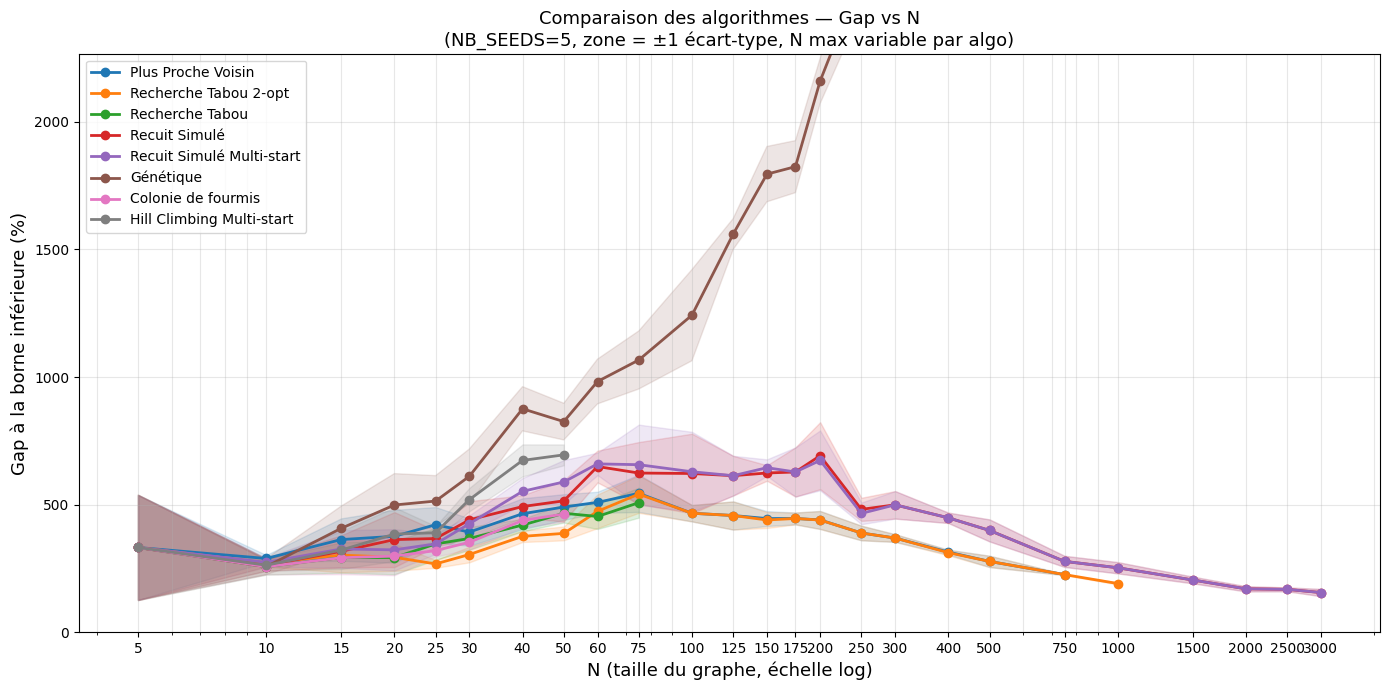

In [20]:
df_results = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(14, 7))

colors = cm.tab10.colors
algo_names = ALGO_ORDER

all_means: list[float] = []

for i, algo_name in enumerate(algo_names):
    sub = df_results[df_results["Algorithme"] == algo_name].sort_values("N")
    if sub.empty:
        continue
    ns = sub["N"].values
    means = sub["gap_mean"].values
    stds = sub["gap_std"].values
    color = colors[i % len(colors)]

    valid = np.isfinite(means) & np.isfinite(stds)
    if valid.sum() == 0:
        print(f"[SKIP] {algo_name} — aucun résultat valide")
        continue
    if valid.sum() < len(ns):
        skipped = ns[~valid].tolist()
        print(f"[WARN] {algo_name} — N={skipped} ignorés (aucune solution trouvée)")

    all_means.extend(means[valid].tolist())
    ax.plot(ns[valid], means[valid], marker="o", linewidth=2, label=algo_name, color=color)
    ax.fill_between(
        ns[valid],
        np.maximum(means[valid] - stds[valid], 0),
        means[valid] + stds[valid],
        alpha=0.15,
        color=color,
    )

if all_means:
    y_cap = np.percentile(all_means, 95) * 1.4
    ax.set_ylim(bottom=0, top=y_cap)

ax.set_xscale("log")
ax.set_xticks(ALL_N_VALUES)
ax.set_xticklabels([str(n) for n in ALL_N_VALUES])
ax.set_xlabel("N (taille du graphe, échelle log)", fontsize=13)
ax.set_ylabel("Gap à la borne inférieure (%)", fontsize=13)
ax.set_title(
    f"Comparaison des algorithmes — Gap vs N\n"
    f"(NB_SEEDS={NB_SEEDS}, zone = ±1 écart-type, N max variable par algo)",
    fontsize=13,
)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

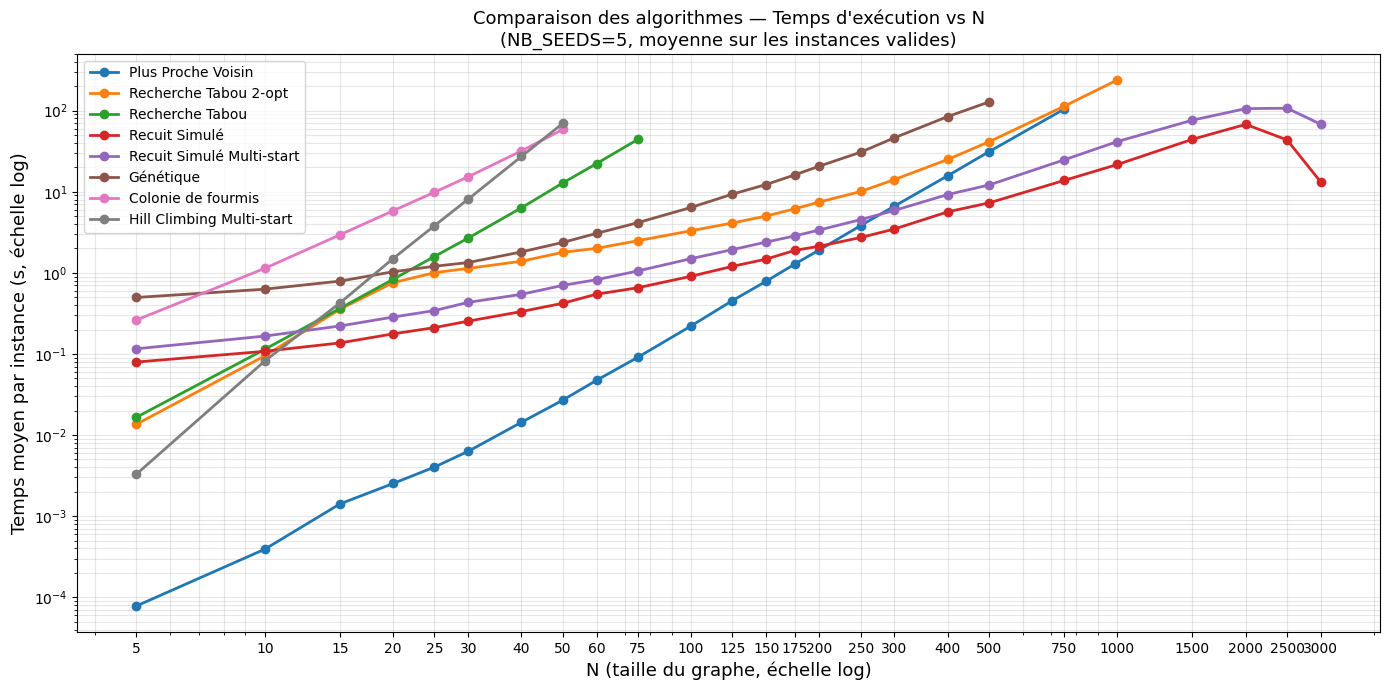

In [21]:
df_time = pd.DataFrame(time_records)

fig, ax = plt.subplots(figsize=(14, 7))

colors = cm.tab10.colors

for i, algo_name in enumerate(ALGO_ORDER):
    sub = df_time[df_time["Algorithme"] == algo_name].sort_values("N")
    if sub.empty:
        continue
    ns = sub["N"].values
    times = sub["time_mean"].values
    valid = np.isfinite(times)
    if valid.sum() == 0:
        continue
    color = colors[i % len(colors)]
    ax.plot(ns[valid], times[valid], marker="o", linewidth=2, label=algo_name, color=color)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(ALL_N_VALUES)
ax.set_xticklabels([str(n) for n in ALL_N_VALUES])
ax.set_xlabel("N (taille du graphe, échelle log)", fontsize=13)
ax.set_ylabel("Temps moyen par instance (s, échelle log)", fontsize=13)
ax.set_title(
    f"Comparaison des algorithmes — Temps d'exécution vs N\n"
    f"(NB_SEEDS={NB_SEEDS}, moyenne sur les instances valides)",
    fontsize=13,
)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Interprétation 
Le graphe compare le gap à la borne inférieure de plusieurs algorithmes TSP en fonction de la taille du graphe N, sur 15 seeds. Plus le gap est bas, meilleur est l'algorithme.

Premier constat : tous les algorithmes sont très loin de la borne inférieure, entre 200% et 900%. Soit la borne est très lâche, soit les algorithmes sont mal calibrés. À vérifier en priorité.

À petite taille (N < 20), les algorithmes sont indistinguables car la variance est énorme. Les bandes de confiance se chevauchent toutes. 15 seeds ne suffisent pas pour tirer des conclusions à ce régime.

Le spike à N=50 est anormal. Recuit Simulé MS monte à ~900%, Recuit Simulé et Genetic suivent. C'est probablement un artefact : hyperparamètres mal calibrés pour cette taille, ou une seed particulièrement pathologique. À investiguer.

À grande taille (N > 100), deux tendances se dégagent. Nearest Neighbor et Tabu Search 2-opt améliorent leur gap relatif en descendant vers 200-280% à N=1000. Les Recuit Simulé stagnent autour de 600%. Genetic, Ant System et HCMS disparaissent du graphe dès N=75-200, ils ne scalent pas.

Le point le plus contre-intuitif : Nearest Neighbor bat Recuit Simulé à grand N. L'explication probable est que le budget de temps est fixe, donc Recuit fait proportionnellement moins d'itérations sur un grand graphe, ce qui rend l'exploration insuffisante.

Conclusion générale : Tabu Search 2-opt est le meilleur compromis sur toute la plage. Recuit Simulé MS n'apporte rien par rapport à Recuit simple. Le spike à N=50 mérite une investigation avant de tirer des conclusions sur ces deux variantes.

In [ ]:
df_results = pd.DataFrame(records)

table = df_results.pivot(index="N", columns="Algorithme", values="gap_mean")
table.columns.name = None
table.index.name = "N"

ordered_cols = [c for c in ALGO_ORDER if c in table.columns]
table = table[ordered_cols].round(2)

try:
    display(
        table.style
        .background_gradient(cmap="RdYlGn_r", axis=1)
        .set_caption(f"Gap moyen (%) par algorithme et par N — {NB_SEEDS} instances/N (— = algo non évalué à ce N)")
        .format("{:.2f}", na_rep="—")
    )
except AttributeError:
    display(table)

,Plus Proche Voisin,Recherche Tabou 2-opt,Recuit Simulé,Recuit Simulé Multi-start
N,,,,
5,440.10,333.40,377.58,377.58
10,296.98,265.42,252.49,259.57
15,356.98,286.34,313.10,314.35
20,373.66,294.28,369.06,347.56
25,432.77,274.74,376.00,368.44
30,414.19,316.37,765.56,792.38
40,453.38,362.34,485.84,540.80
50,476.38,392.54,1060.68,1094.46
60,484.62,449.67,641.64,665.60
